In [135]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer, StandardScaler
import seaborn as sns



cwd= os.getcwd()
path = os.path.join(cwd,'data')

In [136]:
pt = os.path.join(path, 'test.csv')
test_df = pd.read_csv(pt)
pt = os.path.join(path, 'train.csv')
train_df = pd.read_csv(pt)

train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


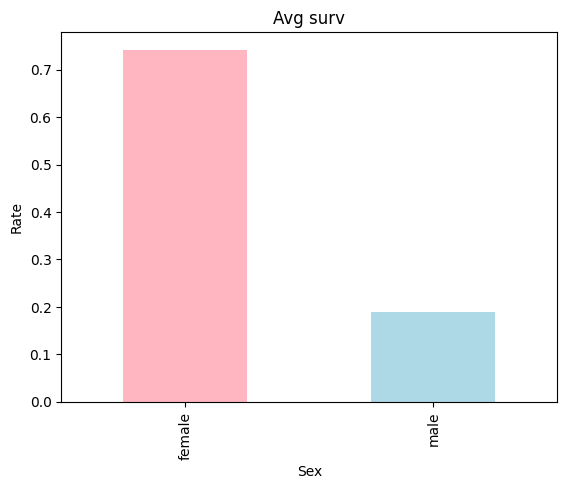

In [137]:
survival_by_gender = train_df.groupby('Sex')['Survived'].mean()

survival_by_gender.plot(kind='bar', color=['lightpink', 'lightblue'])
plt.title('Avg surv')
plt.ylabel('Rate')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12580\3669840136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train_df, ax=axes[0], palette='viridis')


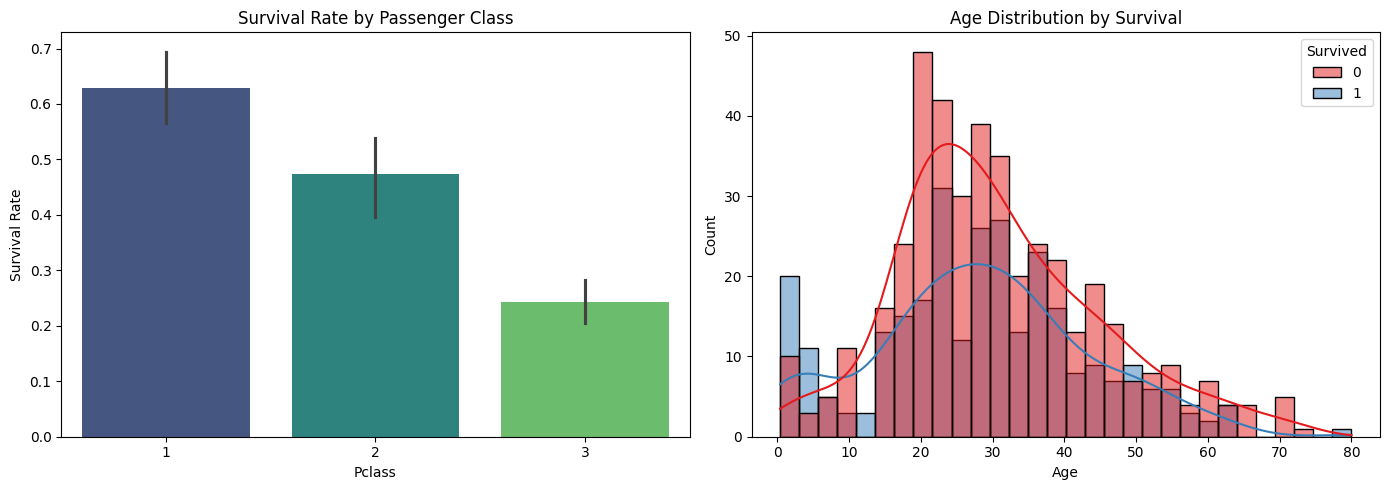

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Pclass', y='Survived', data=train_df, ax=axes[0], palette='viridis')
axes[0].set_title('Survival Rate by Passenger Class')
axes[0].set_ylabel('Survival Rate')

sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[1], palette='Set1', bins=30)
axes[1].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.show()

In [139]:
def features(df_f):
    df = df_f.copy()
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
    df['Title'] = df['Title'].replace(rare_titles, 'Rare')
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    df['Title'] = df['Title'].fillna('Unknown')
    
    df['Family'] = df['SibSp'] + df['Parch']
    df['IsAlone'] = (df['Family'] == 0).astype(int)
    
    columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    return df

categorical_cols = ['Sex', 'Embarked', 'Title']
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family', 'IsAlone']

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('categorical', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), categorical_cols)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('feature_engineer', FunctionTransformer(features)),
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=3))
])

<>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12580\1076875150.py:3: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [140]:
X = train_df.drop(columns=['Survived'])
y = train_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_accuracy

0.8071748878923767

In [141]:
pipeline.fit(X, y)

y_pred_final = pipeline.predict(test_df)

In [142]:
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],  
    'Survived': y_pred_final.astype(int)   
})
submission.to_csv('submission.csv', index=False)
submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


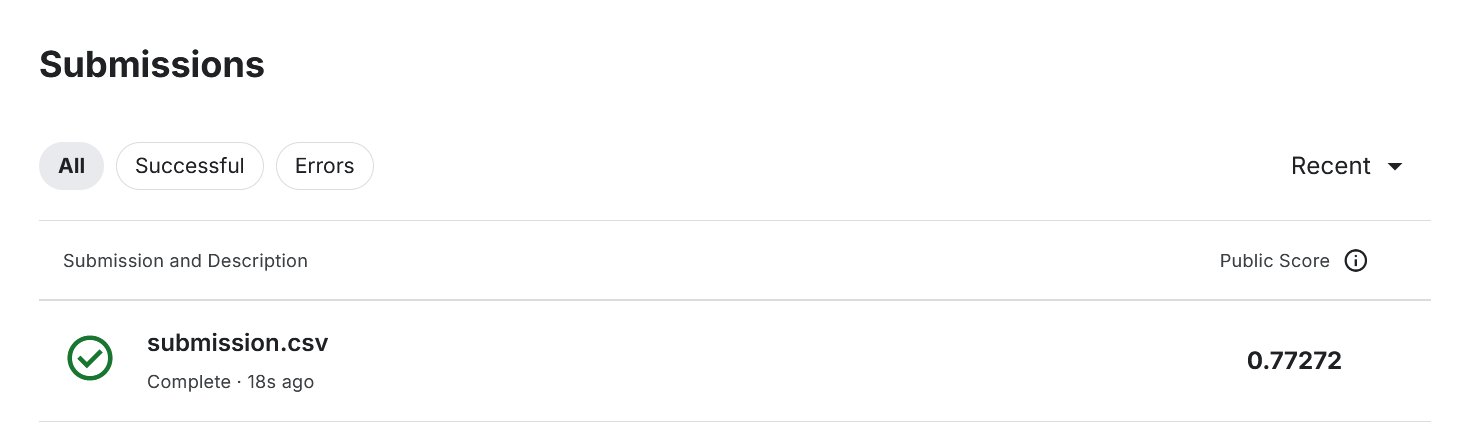